# Introduction to EXOPy

## Installation

The latest version of EXOPy is incorporated within the PyMieDAP program. Detailed instructions on how to install PyMieDAP are avaiable through its [documentation file](../pymiedap_tutorial.ipynb).

## Overview of the model

A simplified flow diagram sketching the various components of EXOPy and their order of use, the overall inputs/outputs, as well as the interaction with the PyMieDAP tool, is found below.

![alt text](exopy_diagram.png "Big Picture")

All computations carried out by the EXOPy tool make use of what we call the 'body' type of python objects. These serve as container for all input parameters and output values, and as interface with the EXOPy functions, for each body involved in the planetary system.

Besides the user needs to specify a set of basic model settings such as which is the observer position with respect to the planetary system reference frame or which is the reference body used for combining the reflected starlight. More details on this operatinos are given afterwards in this tutorial.

Once defined and specified the inputs for each body object, the computation of the orbits can be conducted, as well as the determination of the geometric values which are required for further steps. Afterwards, the pixel shadowing of each body due to phase angle, transit and/or eclipse events are computed as follows from the flowchart.

Finally, the flux and polarization status of the reflected starlight by each body is computed by using some of the modules at PyMieDAP and the various results can be merged in a single planetary system signal.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Getting started

The EXOPy model is contained in the PyMieDAP model folder. To import it, the user can type:

In [2]:
import pymiedap.exopy as exopy

being exopy the acronym employed for the model.

The functions contained in the exopy tool are:

 * **exopy.new_body:** Function generating 'body objects'.
 * **exopy.new_system:** Function loading a pre-defined system of 'body' objects.
 * **exopy.cfg:** Configuration parameters of the EXOPy model.
 * **exopy.compute:** EXOPy object containing all functions required to perform the simulation.
 * **exopy.plot:** EXOPy object containing shorcut functions for visualization of results.
 * **exopy.run_simulation:** Pre-defined script containing basic instructions for running an EXOPy simulation.

The first step towards carrying out the required simulations is the definition of the bodies involved. In this particular case, we're trying to model the Earth-Moon-Sun system, so:

In [3]:
Earth = exopy.new_body('Earth', 'planet')
Moon  = exopy.new_body('Moon' , 'moon'  )
Sun   = exopy.new_body('Sun'  , 'star'  )

    ✓ New planet Earth created!
    ✓ New moon Moon created!
    ✓ New star Sun created!


Basic properties of these bodies which need to be provided to EXOPy are found under the *properties* category, i.e. radius and mass (*R*, *m*).

In [4]:
Earth.properties.R = 6370E3  # [m]

In [5]:
Earth.properties.m = 6E24    # [kg]

This input values, together with the orbital elements of the bodies, can be stored at the exopy.py script and therefore retrieved through the *exopy.new_system* functions as:

In [6]:
[Moon, Earth, Sun], conf = exopy.new_system('s_system')
print(conf)

    ✓ New planet Planet created!
    ! The object has been overwritten in the body list...
    ✓ New moon Moon created!
    ! The object has been overwritten in the body list...
    ✓ New star Sun created!
<pymiedap.exopy_source.exopy_config.Settings instance at 0x7fab05879cf8>


where 's_system' is the string associated to the solar system predefined scenario (Earth-Moon-Sun system).

Before continuing, the user needs to set up a couple of model configuration parameters:
- **Observer's location:** characterized by the spherical coordinates given by an azimuth and elevation angle in degrees.

In [7]:
conf.az = 0 # [deg]
conf.el = 0 # [deg

- **Reference elements:** reference line and reference body for the computation of reflected starlight.

In [8]:
conf.ref_body = 'Planet'
conf.ref_line = 'Planet'

## Documentation

All functions, methods and objects in EXOPy are accompanied with a brief documentation providing information regarding the purpose, useage and/or parameteres stored in each case, as well as units and format information. 

The user can access this documentation by typing '?', e.g.:

In [9]:
exopy?

In [10]:
exopy.new_system?

In [11]:
Earth?

In [12]:
Earth.grid?

Moreover, methods and objects can be mentioned and/or called for getting generic information regarding the parameteres and variables involved or specific values at a particular time (pixel) index, e.g.:

In [13]:
Earth.properties



Relation of body properties:

   Mass: m = 5.972e+24 kg
   Radius: R = 6371008.0 m

Being the orbital elements already pre-defined, the user can print an overview of them as:

In [14]:
Earth.orbital_elements



Relation of orbital elements:

   Bar. semi-major axis (a_b): 1.5e+11 m
   Bar. eccentricity (e_b):    0.0167[-]
   Bar. inclination (i_b):     90.0 deg
   Bar. argument of periapsis (omega_b):    270.0 deg
   Bar. right ascension of the ascending node (Omega_b): 0.0 deg
   Bar. time from periapsis passage (t0_b): 0.0 s
   Bar. eccentric anomaly (E_bs) = () array
   Bar. mean anomaly (M_bs)  = () array
   Bar. true anomaly (nu_bs) = () array

In [15]:
Moon.orbital_elements



Relation of orbital elements:

   Semi-major axis (a): 379750640.981 m
   Eccentricity (e):    0.0549[-]
   Inclination (i):     5.145 deg
   Argument of periapsis (omega):    0.0 deg
   Right ascension of the ascending node (Omega): 0.0 deg
   Time from periapsis passage (t0): 0.0 s
   Eccentric anomaly (E_mb) = () rad
   Mean anomaly (M_mb)  = () rad
   True anomaly (nu_mb) = () rad

These values can be modified at any moment. For this, it is required to understand the conventions established, explained below.

## Defining and computing the orbit position

The orbital motion of the moon and planet around the star is computed under the assumption of a Nested Two Body Proble, i.e. it is assumed that the star does not alter the movement of the moon around the planet-moon system barycentre, while the barycentre of the system describes a Kepler orbit around the star.

The input orbital elements required for carrying out the orbits computation is different for planet and moon type of bodies, while the star does not play any role. By convention, for a planet type of object we store the information of the planet-moon system barycentre:

 - **a_b:** semi-major axis of the planet-moon system barycentre's orbit around the star [m] (float)
 - **e_b:** eccentricity of the planet-moon system barycentre's orbit around the star [-] (float)
 - **i_b:** inclination of the planet-moon system barycentre's orbit around the star [deg] (float)
 - **Omega_b:** Right Ascension of the Ascending Node of the planet-moon system barycentre's orbit around the star [deg] (float)
 - **omega_b:** Argument of periapsis of the planet-moon system barycentre's orbit around the star [deg] (float)
 - **t0_b:** time since last periapsis passage of the planet-moon system barycentre's orbit around the star [s] (float)
 
In the case of the moon, the information of the moon's orbit around the planet-moon system barycentre is stored as:

 - **a:** semi-major axis of the moon's orbit around the planet-moon system barycentre [m] (float)
 - **e:** eccentricity of the moon's orbit around the planet-moon system barycentre [-] (float)
 - **i:** inclination of the moon's orbit around the planet-moon system barycentre [deg] (float)
 - **Omega:** Right Ascension of the Ascending Node of the moon's orbit around the planet-moon system barycentre [deg] (float)
 - **omega:** Argument of periapsis of the moon's orbit around the planet-moon system barycentre [deg] (float)
 - **t0:** time since last periapsis passage of the moon's orbit around the planet-moon system barycentre [s] (float)
 
Specified these values, the user can easily compute the position of the bodies via the compute.orbit exopy function:

In [16]:
[Moon, Planet, Star] = exopy.compute.orbit(Moon, Earth, Sun, delta_t = 60*60*24*5, final_t = 365*60*60*24)

    ✓ The trajectories of Moon, Planet, and Sun have been calculated.



where the last two input parameters are the time step and final time of computation in seconds.

The employed function computes the 3D and 2D position of each body with time and stores it inside the *ephemeris* category. However, it does not compute the angles of interest. For this, use is made of the *exopy.compute.geometry* function. 

Use can be made of the exopy.plot functions to get an overview of the computed orbits.

In [17]:
#exopy.plot.XYZorbit(Earth.ephemeris.position3D_s, Moon.ephemeris.position3D_s)

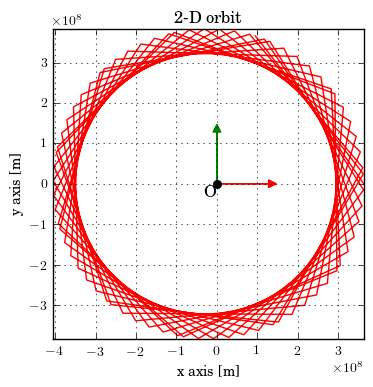

In [18]:
exopy.plot.xyorbit(Moon.ephemeris.position2D_mp)

In [19]:
# from pymiedap.exopy_functions import display_animation

In [20]:
# animation = display_animation(exopy.plot.anim_orbit(Moon.ephemeris.time, Moon.ephemeris.position3D_s));

In [21]:
# animation

## Defining and computing the geometry of the problem

As a first step towards the computation of the full geometry of the problem (pixel and time dependent) is the definition of the grids to be used for the planet and moon bodies through the function *set_grid*. In this case, a regular squared pixels grid of 40 elements along the equator is set for the planet.

In [22]:
Earth.grid.set_grid(grid_type = 'square', Nsq = 40)

  Square grid created!


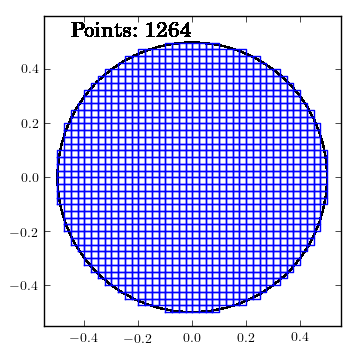

In [23]:
Earth.grid.show_grid()

For the moon, the closest integer number of pixels along the equator that matches the ratio of radii between the planet annd moon is selected:

In [24]:
Moon.grid.set_grid(grid_type = 'square', Nsq = int(np.round(Earth.grid.Nsq*Moon.properties.R/Earth.properties.R)))

  Square grid created!


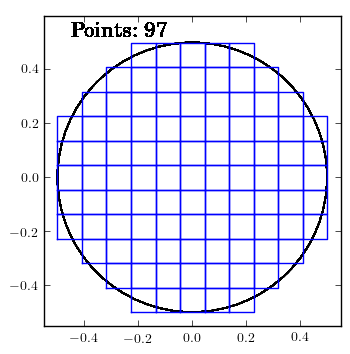

In [25]:
Moon.grid.show_grid()

In [26]:
print(conf.plot_faces)
print(Earth)
Earth, Moon, Sun= exopy.compute.geometry([Earth, Moon, Sun], conf)

True


Body object:

   Name of body:  Planet
   Type of body:  planet
   Note:          

   Radius:  6371008.0 m
   Mass:    5.972e+24 kg
   Density: 5513.23796981 kg/m3
   Surface albedo: 0.0

   Wavelength [nm]	Fourier file
       1.101		


Relation of body flag indicators:

   Orbit geometry calculated:	False
   Phase shadow calculated:	False
   Transits shadow calculated:	False
   Eclipses shadow calculated:	False
   Reflected light calculated:	False
   Reflected light combined:	False



Relation of orbital elements:

   Bar. semi-major axis (a_b): 1.5e+11 m
   Bar. eccentricity (e_b):    0.0167[-]
   Bar. inclination (i_b):     90.0 deg
   Bar. argument of periapsis (omega_b):    270.0 deg
   Bar. right ascension of the ascending node (Omega_b): 0.0 deg
   Bar. time from periapsis passage (t0_b): 0.0 s

   Grid type:	Square
   Grid points:	1264
   Grid eq. points: 40

Relation of properties at time index 'i' available through body(i).

    ... geometry of planet Planet


    ...

The new information generated is stored under the category *geometry* of each body. For instance, at time index 100 we have for planet Earth:

In [27]:
Earth.geometry(100, unit = 'deg')



   ! Index is larger than arrays' dimension


At this point, the planet and moon bodies are considered to be fully illuminated as seen from the observer's position, as the plot below shows:

0

    ⇒ Plotting shadow of planet Planet at t =10800000.0 seconds
    ... Caution: discrete phase data not available for planet Planet!
    ... Caution: discrete transit data not available for planet Planet!
    ... Caution: discrete eclipse data not available for planet Planet!


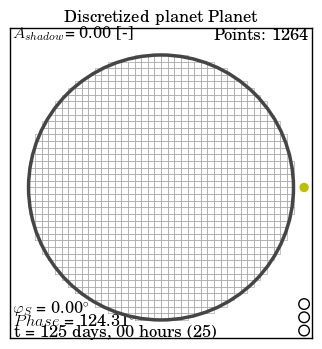

In [28]:
print(conf.plot_color)
exopy.plot.shadow_d(Earth, conf, t=25)

In order to computed the pixel darkening due to shadowing effects the user can employ the phase, transits and eclipses funtions.

## Computing the pixel darkenning 

EXOPy allows to compute the pixel darkenning due to three different sources:

- **Phase angle:** Along the orbit, just part of the body will be visible from the observer's position. The function *exopy.compute.phases* takes care of this factor:

In [29]:
Earth, Moon = exopy.compute.phases([Earth, Moon], Sun, conf)


    ... phase of planet Planet


    ... phase of moon Moon



- **Transit events:** The interposition of one body between the targeted body and the observer results in a partial (or total) blockage of the reflected light:

In [30]:
Moon, Earth, Sun = exopy.compute.transits([Moon, Earth, Sun], conf)


    ... transits between moon Moon and planet Planet


    ... transits between moon Moon and star Sun


    ... transits between planet Planet and star Sun



- **Eclipse events:** The interposition of one body between the targeted body and the star results in a gradual blockage of the reflected light:

In [31]:
Moon, Earth = exopy.compute.eclipses([Moon, Earth], Sun, conf)


    ... eclipses between moon Moon and planet Planet


    ... eclipses between planet Planet and moon Moon



pymiedap/exopy_source/exopy_eclipse.py:283: RuntimeWarning: invalid value encountered in greater
  partial_umbra_times = (remaining) & (costheta>cosPSI) & ( (R_A2P_norm > Radi/tanPSI) | (R_A3P_norm < Radi) )
pymiedap/exopy_source/exopy_eclipse.py:300: RuntimeWarning: invalid value encountered in less
  partial_umbra = (sinbeta < sinPSI[:,np.newaxis]) & (partial_umbra_nodes)


In our example, we can observe the moon eclipsing the Earth at time index equal 0:


    ⇒ Plotting shadow of planet Planet at t =0.0 seconds


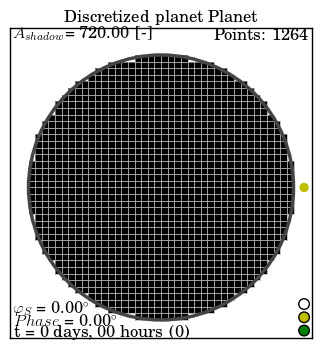

In [32]:
exopy.plot.shadow_d(Earth, conf, t = 0)

At this point, we can compute the reflected starlight.

## Setting the atmosphere and surface properties

Computing the reflected starlight of each body requires to specify which are the surface and atmosphere properties as well as at which wavelength are we working on. For this, use is made of the PyMieDAP *atmosphere* class which can be configured according to the advice given in [here](pymiedap_tuto.html). 

Alternatively, the user can employ one of the pre-defined atomospheric models and tune it through any of the available input values using the exopy module called *atm_model*.

In this case, the Earth has been granted with a cloudy model in the blue, while a lambertian surface model of albedo 0.1 has been employed for the Moon surface:

In [33]:
Earth.atmosphere = exopy.atm_models.Earth()[0]
Moon.atmosphere  = exopy.atm_models.Moon(alb = 0.1)[0]

## Computing reflected starlight

As a last step, the reflected starlight at each pixel is integrated along the entire disk for computing the polarized reflected signal of each body independently. This is done through the function *exopy.compute.int_radiance* as:

**! Mind that this process can take a long time depending on the Fourier files to be read, the number of pixels, and the time vector to be covered.**

In [34]:
[Earth, Moon] = exopy.compute.int_radiance([Earth, Moon])


    ... integrating radiance on planet Planet disk 

(1, ' out of ', 73)
In layer gasbelow:
Beginning of Mie program
Wavelength 0.4000000
End of Mie program
Aerosols mixed!
In layer gastop:
Beginning of Mie program
Wavelength 0.4000000
End of Mie program
Aerosols mixed!
In layer cloud:
Beginning of Mie program
Wavelength 0.4000000
End of Mie program
Aerosols mixed!
Beginning of DAP program
Wavelength 0.4000000 microns
C.sc.0.4000000
C.sc.0.4000000
C.sc.0.4000000
fou_0.4000000.dat
End of DAP program
(2, ' out of ', 73)
(3, ' out of ', 73)
(4, ' out of ', 73)
(5, ' out of ', 73)
(6, ' out of ', 73)
(7, ' out of ', 73)
(8, ' out of ', 73)
(9, ' out of ', 73)
(10, ' out of ', 73)
(11, ' out of ', 73)
(12, ' out of ', 73)
(13, ' out of ', 73)
(14, ' out of ', 73)
(15, ' out of ', 73)
(16, ' out of ', 73)
(17, ' out of ', 73)
(18, ' out of ', 73)
(19, ' out of ', 73)
(20, ' out of ', 73)
(21, ' out of ', 73)
(22, ' out of ', 73)
(23, ' out of ', 73)
(24, ' out of ', 73)
(25, ' out of ', 73)

pymiedap/exopy_source/exopy_radiance.py:237: RuntimeWarning: invalid value encountered in divide
  body.radiance.P   = np.sqrt(Qp**2 + Up**2)/Ip*100
pymiedap/exopy_source/exopy_radiance.py:238: RuntimeWarning: invalid value encountered in divide
  body.radiance.Chi = 0.5*np.rad2deg(np.arctan(Up/Qp))



    ... integrating radiance on moon Moon disk 

(1, ' out of ', 73)
In layer gasbelow:
Beginning of Mie program
Wavelength 0.4000000
End of Mie program
Aerosols mixed!
In layer gastop:
Beginning of Mie program
Wavelength 0.4000000
End of Mie program
Aerosols mixed!
In layer cloud:
Beginning of Mie program
Wavelength 0.4000000
End of Mie program
Aerosols mixed!
Beginning of DAP program
Wavelength 0.4000000 microns
C.sc.0.4000000
C.sc.0.4000000
C.sc.0.4000000
fou_0.4000000.dat
End of DAP program
(2, ' out of ', 73)
(3, ' out of ', 73)
(4, ' out of ', 73)
(5, ' out of ', 73)
(6, ' out of ', 73)
(7, ' out of ', 73)
(8, ' out of ', 73)
(9, ' out of ', 73)
(10, ' out of ', 73)
(11, ' out of ', 73)
(12, ' out of ', 73)
(13, ' out of ', 73)
(14, ' out of ', 73)
(15, ' out of ', 73)
(16, ' out of ', 73)
(17, ' out of ', 73)
(18, ' out of ', 73)
(19, ' out of ', 73)
(20, ' out of ', 73)
(21, ' out of ', 73)
(22, ' out of ', 73)
(23, ' out of ', 73)
(24, ' out of ', 73)
(25, ' out of ', 73)
(26

As output, the discretized reflected signals as well as the integrated signals are obtained. These can be easily plotted through some of the pre-defined display functions as follows:


    ⇒ Plotting stokes parameters of planet Planet at t =0.0 seconds


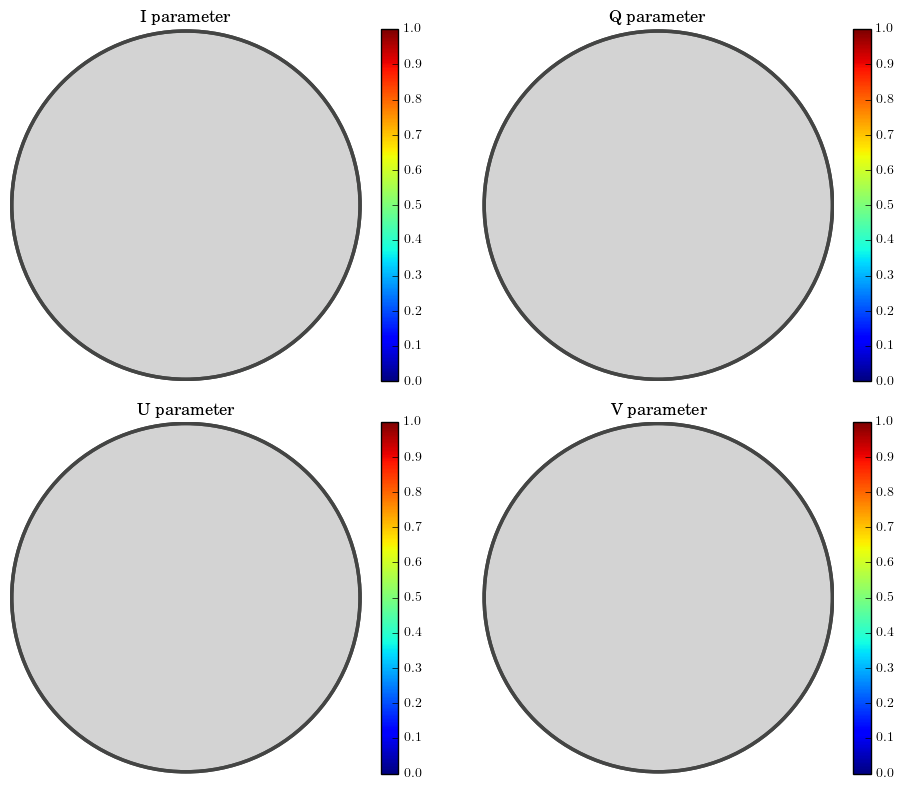

In [35]:
exopy.plot.radiance_d(Earth, conf)

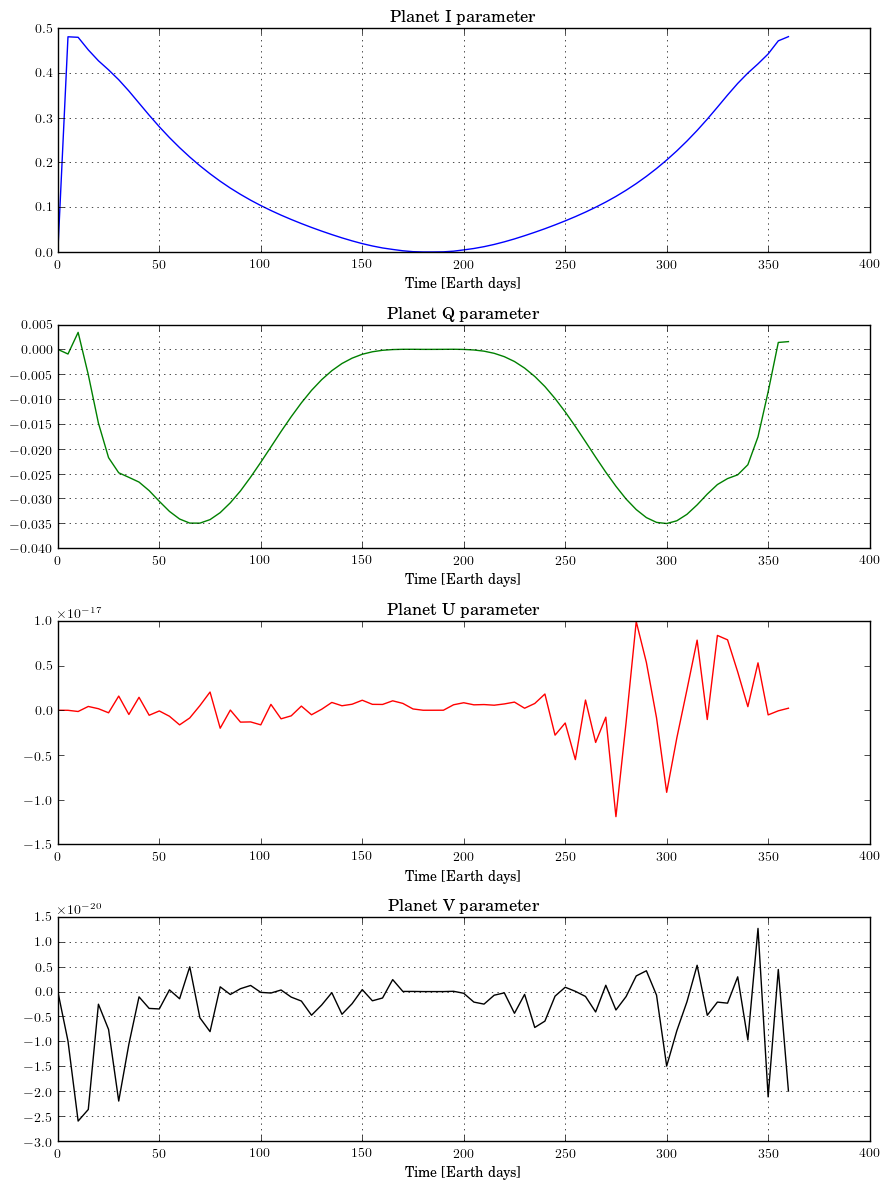

In [36]:
exopy.plot.radiance(Earth)

Finally, the individual signals are combined taking one particular body and one particular scattering plane as reference through the *exopy.compute.combine* function.

In [37]:
I,Q,U,V,P,Chi = exopy.compute.combine([Earth, Moon], conf)


    ... combining radiance results



pymiedap/exopy_source/exopy_radiance.py:110: RuntimeWarning: invalid value encountered in divide
  P[wvl,:]   = np.sqrt(Q[wvl,:]**2 + U[wvl,:]**2)/I[wvl,:]*100
pymiedap/exopy_source/exopy_radiance.py:111: RuntimeWarning: invalid value encountered in divide
  Chi[wvl,:] = 0.5*np.rad2deg(np.arctan(U[wvl,:]/Q[wvl,:]))


In [38]:
Earth.geometry.ref_plane_to_ref_line_angle

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [39]:
Moon.geometry.ref_plane_to_ref_line_angle

array([  0.00000000e+00,  -2.39670478e-03,  -9.39676169e-04,
         2.60031816e-04,   6.68322632e-04,   2.87956141e-04,
        -2.80474209e-04,  -3.86134600e-04,  -7.22483909e-05,
         2.54370807e-04,   2.68839714e-04,  -2.89925325e-05,
        -2.55477507e-04,  -1.64371860e-04,   9.29893053e-05,
         2.38228207e-04,   1.02287720e-04,  -1.58612358e-04,
        -2.14772111e-04,  -2.54158989e-05,   1.94571301e-04,
         1.99741384e-04,  -4.97756464e-05,  -2.46528046e-04,
        -1.50006227e-04,   1.27858505e-04,   2.93542957e-04,
         1.08178713e-04,  -2.60017530e-04,  -3.41609180e-04,
        -7.75648306e-06,   4.43060629e-04,   4.71608374e-04,
        -2.29497555e-04,  -1.01525464e-03,  -8.04646700e-04,
         2.27396050e-03,   6.27570191e+00,   6.28268703e+00,
        -6.28221024e+00,  -6.28247174e+00,   6.28313740e+00,
         6.28269968e+00,   6.28286306e+00,  -6.28302614e+00,
        -6.28282907e+00,  -6.28305148e+00,   6.28299978e+00,
         6.28291281e+00,

Again, the final results can be displayed for the overall planetary system:

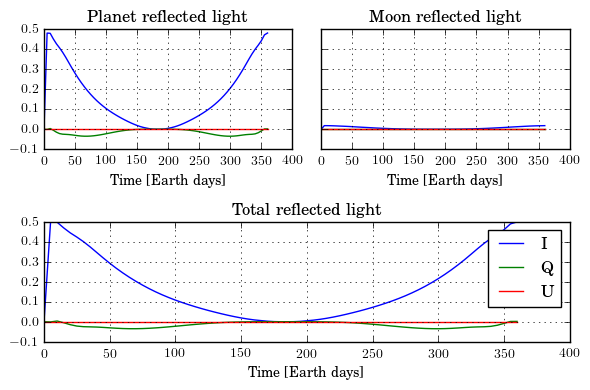

In [40]:
exopy.plot.detail_radiance([Earth,Moon], I, Q, U, V)